# Tier 2 Deep Learning Models

This notebook extends the fraud detection modeling pipeline from traditional machine learning to deep learning.

The first Tier 2 model is a Multilayer Perceptron (MLP) implemented with PyTorch. The model reuses the processed and scaled datasets produced during the data preparation phase, preserving the same chronological train, validation, and test splits used for the Tier 1 baseline models.

Average Precision (AP) remains the primary evaluation metric because of the extreme class imbalance in the fraud detection problem. Precision, Recall, F1-score, ROC-AUC, and the confusion matrix will be used as complementary diagnostic metrics.

The validation set will be used for model development and comparison. The test set remains reserved for final evaluation and will not be used for model selection or hyperparameter decisions.

## 1. Data Handoff and Environment

In [116]:
# Import standard library modules used for reproducibility and path management.
import random
from pathlib import Path

# Import numerical and tabular data libraries.
import numpy as np
import pandas as pd

# Import Matplotlib for model evaluation visualizations.
import matplotlib.pyplot as plt

# Import PyTorch and the modules required to build and train the MLP.
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Import evaluation metrics from scikit-learn.
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

### 1.0 Reproducible Configuration

In [117]:
# Define a fixed random seed to make the MLP experiment reproducible.
RANDOM_SEED = 42

# Set the Python random seed.
random.seed(RANDOM_SEED)

# Set the NumPy random seed.
np.random.seed(RANDOM_SEED)

# Set the PyTorch CPU random seed.
torch.manual_seed(RANDOM_SEED)

# Set the PyTorch CUDA random seed when a GPU is available.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Configure deterministic CUDA behavior where supported.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Print the configured seed.
print(f"Random seed: {RANDOM_SEED}")

Random seed: 42


### 1.1 Project Paths

In [118]:
# Define the project root directory relative to this notebook.
PROJECT_ROOT = Path("..")

# Define the directories used by the project.
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

# Define the processed datasets produced by the data preparation notebook.
X_TRAIN_PATH = PROCESSED_DIR / "X_train_scaled.parquet"
X_VAL_PATH = PROCESSED_DIR / "X_val_scaled.parquet"
X_TEST_PATH = PROCESSED_DIR / "X_test_scaled.parquet"

Y_TRAIN_PATH = PROCESSED_DIR / "y_train.parquet"
Y_VAL_PATH = PROCESSED_DIR / "y_val.parquet"
Y_TEST_PATH = PROCESSED_DIR / "y_test.parquet"

# Print the resolved project paths to verify the notebook location and file structure.
print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"Processed data directory: {PROCESSED_DIR.resolve()}")
print(f"Models directory: {MODELS_DIR.resolve()}")

Project root: /home/anderjcruz/projects/Bank-Fraud-Detection
Processed data directory: /home/anderjcruz/projects/Bank-Fraud-Detection/data/processed
Models directory: /home/anderjcruz/projects/Bank-Fraud-Detection/models


### 1.2 Processed Dataset Availability

In [119]:
# Store all processed dataset paths in a dictionary for a single availability check.
processed_files = {
    "X_train_scaled": X_TRAIN_PATH,
    "X_val_scaled": X_VAL_PATH,
    "X_test_scaled": X_TEST_PATH,
    "y_train": Y_TRAIN_PATH,
    "y_val": Y_VAL_PATH,
    "y_test": Y_TEST_PATH,
}

# Check whether every required processed dataset exists.
for file_name, file_path in processed_files.items():
    print(f"{file_name}: {file_path.exists()}")

X_train_scaled: True
X_val_scaled: True
X_test_scaled: True
y_train: True
y_val: True
y_test: True


### 1.3 Load Processed Datasets

In [120]:
# Load the scaled feature matrices produced by the data preparation phase.
X_train = pd.read_parquet(X_TRAIN_PATH)
X_val = pd.read_parquet(X_VAL_PATH)
X_test = pd.read_parquet(X_TEST_PATH)

# Load the target vectors for the training, validation, and test splits.
y_train = pd.read_parquet(Y_TRAIN_PATH).squeeze("columns")
y_val = pd.read_parquet(Y_VAL_PATH).squeeze("columns")
y_test = pd.read_parquet(Y_TEST_PATH).squeeze("columns")

# Print the shapes of all loaded datasets to verify the data handoff.
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (199364, 32)
X_val shape:   (42721, 32)
X_test shape:  (42722, 32)
y_train shape: (199364,)
y_val shape:   (42721,)
y_test shape:  (42722,)


### 1.4 Feature Contract

In [121]:
# Define the expected feature order established during data preparation.
EXPECTED_FEATURES = (
    [f"V{i}" for i in range(1, 29)]
    + ["Amount", "Amount_log", "Time", "Time_hour"]
)

# Verify that all splits contain exactly the expected features in the same order.
train_features_match = X_train.columns.tolist() == EXPECTED_FEATURES
val_features_match = X_val.columns.tolist() == EXPECTED_FEATURES
test_features_match = X_test.columns.tolist() == EXPECTED_FEATURES

# Print the feature contract validation results.
print(f"Number of expected features: {len(EXPECTED_FEATURES)}")
print(f"Train feature contract:      {train_features_match}")
print(f"Validation feature contract: {val_features_match}")
print(f"Test feature contract:       {test_features_match}")

# Display the feature names to make the input contract explicit.
print("\nFeature order:")
print(EXPECTED_FEATURES)

Number of expected features: 32
Train feature contract:      True
Validation feature contract: True
Test feature contract:       True

Feature order:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Amount_log', 'Time', 'Time_hour']


### 1.5 Convert Data to PyTorch Tensors

In [122]:
# Convert the scaled feature matrices to writable NumPy arrays with float32 precision.
X_train_array = X_train.to_numpy(dtype=np.float32, copy=True)
X_val_array = X_val.to_numpy(dtype=np.float32, copy=True)
X_test_array = X_test.to_numpy(dtype=np.float32, copy=True)

# Convert the target vectors to writable NumPy arrays with float32 precision.
y_train_array = y_train.to_numpy(dtype=np.float32, copy=True)
y_val_array = y_val.to_numpy(dtype=np.float32, copy=True)
y_test_array = y_test.to_numpy(dtype=np.float32, copy=True)

# Convert the NumPy arrays to PyTorch tensors.
X_train_tensor = torch.from_numpy(X_train_array)
X_val_tensor = torch.from_numpy(X_val_array)
X_test_tensor = torch.from_numpy(X_test_array)

y_train_tensor = torch.from_numpy(y_train_array)
y_val_tensor = torch.from_numpy(y_val_array)
y_test_tensor = torch.from_numpy(y_test_array)

# Print tensor shapes and data types to verify the conversion.
print(f"X_train tensor: {X_train_tensor.shape}, {X_train_tensor.dtype}")
print(f"y_train tensor: {y_train_tensor.shape}, {y_train_tensor.dtype}")
print(f"X_val tensor:   {X_val_tensor.shape}, {X_val_tensor.dtype}")
print(f"y_val tensor:   {y_val_tensor.shape}, {y_val_tensor.dtype}")
print(f"X_test tensor:  {X_test_tensor.shape}, {X_test_tensor.dtype}")
print(f"y_test tensor:  {y_test_tensor.shape}, {y_test_tensor.dtype}")

X_train tensor: torch.Size([199364, 32]), torch.float32
y_train tensor: torch.Size([199364]), torch.float32
X_val tensor:   torch.Size([42721, 32]), torch.float32
y_val tensor:   torch.Size([42721]), torch.float32
X_test tensor:  torch.Size([42722, 32]), torch.float32
y_test tensor:  torch.Size([42722]), torch.float32


### 1.6 TensorDataset and DataLoader

In [123]:
# Combine the training features and targets into a PyTorch dataset.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# Combine the validation features and targets into a PyTorch dataset.
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Combine the test features and targets into a PyTorch dataset.
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Print the number of samples in each dataset.
print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples:       {len(test_dataset)}")

Training samples:   199364
Validation samples: 42721
Test samples:       42722


### 1.7 Create DataLoaders

In [124]:
# Define the batch size used during MLP training.
BATCH_SIZE = 1024

# Create the training DataLoader with shuffled mini-batches.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

# Create the validation DataLoader without shuffling the validation data.
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Create the test DataLoader without shuffling the test data.
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Calculate the number of batches in each DataLoader.
print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

Training batches:   195
Validation batches: 42
Test batches:       42


### 1.7.1 Reproducible Training DataLoader

In [125]:
# Create a dedicated PyTorch generator for reproducible batch shuffling.
train_generator = torch.Generator()

# Set the generator seed.
train_generator.manual_seed(RANDOM_SEED)

# Recreate the training DataLoader using the fixed generator.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
)

# Recreate the validation DataLoader without shuffling.
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Recreate the test DataLoader without shuffling.
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Print the DataLoader configuration.
print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

Training batches:   195
Validation batches: 42
Test batches:       42


### 1.8 Training Batch Inspection

In [126]:
# Retrieve the first mini-batch from the training DataLoader.
first_batch_features, first_batch_targets = next(iter(train_loader))

# Count the number of legitimate and fraudulent transactions in the batch.
batch_legitimate = (first_batch_targets == 0).sum().item()
batch_fraud = (first_batch_targets == 1).sum().item()

# Print the batch shapes and class distribution.
print(f"Batch features shape: {first_batch_features.shape}")
print(f"Batch targets shape:  {first_batch_targets.shape}")
print(f"Legitimate samples:   {batch_legitimate}")
print(f"Fraud samples:        {batch_fraud}")

Batch features shape: torch.Size([1024, 32])
Batch targets shape:  torch.Size([1024])
Legitimate samples:   1023
Fraud samples:        1


### 1.9 Compute Device

In [127]:
# Select the CUDA GPU when it is available; otherwise, use the CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Print the selected computation device.
print(f"Selected device: {device}")

# Print the GPU name when CUDA is available.
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Selected device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## 2. Multilayer Perceptron Architecture

### 2.1 MLP Configuration

In [128]:
# Define the number of input features expected by the MLP.
INPUT_SIZE = 32

# Define the sizes of the two hidden layers.
HIDDEN_SIZE_1 = 64
HIDDEN_SIZE_2 = 32

# Define the dropout probability used after each hidden layer.
DROPOUT_RATE = 0.20

# Define the number of output units for binary classification.
OUTPUT_SIZE = 1

# Print the planned architecture configuration.
print(f"Input features: {INPUT_SIZE}")
print(f"Hidden layer 1: {HIDDEN_SIZE_1}")
print(f"Hidden layer 2: {HIDDEN_SIZE_2}")
print(f"Dropout rate:   {DROPOUT_RATE}")
print(f"Output units:   {OUTPUT_SIZE}")

Input features: 32
Hidden layer 1: 64
Hidden layer 2: 32
Dropout rate:   0.2
Output units:   1


### 2.2 MLP Model Definition

In [129]:
# Define the Multilayer Perceptron architecture for binary fraud classification.
class FraudMLP(nn.Module):

    # Initialize the neural network layers.
    def __init__(
        self,
        input_size=INPUT_SIZE,
        hidden_size_1=HIDDEN_SIZE_1,
        hidden_size_2=HIDDEN_SIZE_2,
        dropout_rate=DROPOUT_RATE,
        output_size=OUTPUT_SIZE,
    ):
        # Initialize the parent PyTorch module.
        super().__init__()

        # Define the first fully connected layer.
        self.fc1 = nn.Linear(input_size, hidden_size_1)

        # Define the ReLU activation function.
        self.relu1 = nn.ReLU()

        # Define dropout after the first hidden layer.
        self.dropout1 = nn.Dropout(dropout_rate)

        # Define the second fully connected layer.
        self.fc2 = nn.Linear(hidden_size_1, hidden_size_2)

        # Define the second ReLU activation function.
        self.relu2 = nn.ReLU()

        # Define dropout after the second hidden layer.
        self.dropout2 = nn.Dropout(dropout_rate)

        # Define the final output layer.
        self.output = nn.Linear(hidden_size_2, output_size)

    # Define how input data flows through the network.
    def forward(self, x):
        # Transform the input features through the first dense layer.
        x = self.fc1(x)

        # Apply the first nonlinear activation.
        x = self.relu1(x)

        # Apply dropout during training.
        x = self.dropout1(x)

        # Transform the representation through the second dense layer.
        x = self.fc2(x)

        # Apply the second nonlinear activation.
        x = self.relu2(x)

        # Apply dropout during training.
        x = self.dropout2(x)

        # Produce one output logit for binary classification.
        x = self.output(x)

        # Return the output logit without applying sigmoid.
        return x

In [130]:
# Create an instance of the MLP model.
model = FraudMLP()

# Move the model parameters to the selected computation device.
model = model.to(device)

# Print the model architecture.
print(model)

FraudMLP(
  (fc1): Linear(in_features=32, out_features=64, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.2, inplace=False)
  (output): Linear(in_features=32, out_features=1, bias=True)
)


### 2.3 Model Parameter Count

In [131]:
# Calculate the total number of trainable parameters in the MLP.
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

# Print the total number of trainable parameters.
print(f"Trainable parameters: {total_parameters:,}")

Trainable parameters: 4,225


### 2.4 Weighted Binary Cross-Entropy Loss

In [132]:
# Count legitimate and fraudulent transactions in the training set.
negative_count = (y_train_tensor == 0).sum().item()
positive_count = (y_train_tensor == 1).sum().item()

# Calculate the positive-class weight using only the training data.
pos_weight_value = negative_count / positive_count

# Convert the positive-class weight to a PyTorch tensor on the selected device.
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

# Create the weighted binary cross-entropy loss.
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Print the class counts and positive-class weight.
print(f"Negative samples: {negative_count:,}")
print(f"Positive samples: {positive_count:,}")
print(f"Positive class weight: {pos_weight_value:.4f}")

Negative samples: 198,980
Positive samples: 384
Positive class weight: 518.1771


### 2.5 First Forward Pass

In [133]:
# Move the first training batch to the selected computation device.
batch_features = first_batch_features.to(device)
batch_targets = first_batch_targets.to(device)

# Put the model in training mode so dropout is active.
model.train()

# Perform a forward pass through the MLP.
batch_logits = model(batch_features)

# Calculate the weighted binary cross-entropy loss for this batch.
batch_loss = criterion(batch_logits.squeeze(1), batch_targets)

# Convert the logits to probabilities for inspection.
batch_probabilities = torch.sigmoid(batch_logits.squeeze(1))

# Print the output shapes and initial loss.
print(f"Input batch shape:       {batch_features.shape}")
print(f"Model output shape:      {batch_logits.shape}")
print(f"Probability shape:       {batch_probabilities.shape}")
print(f"Initial batch loss:      {batch_loss.item():.6f}")

Input batch shape:       torch.Size([1024, 32])
Model output shape:      torch.Size([1024, 1])
Probability shape:       torch.Size([1024])
Initial batch loss:      0.898796


### 2.6 Optimizer and Single Training Step

In [134]:
# Define the learning rate used by the Adam optimizer.
LEARNING_RATE = 0.001

# Create the Adam optimizer for the MLP parameters.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

# Clear any previously stored gradients.
optimizer.zero_grad()

# Perform a forward pass using the current batch.
batch_logits = model(batch_features)

# Calculate the weighted binary cross-entropy loss.
batch_loss = criterion(batch_logits.squeeze(1), batch_targets)

# Calculate gradients through backpropagation.
batch_loss.backward()

# Update the model parameters using the calculated gradients.
optimizer.step()

# Print the loss after the single optimization step.
print(f"Loss before/at optimization step: {batch_loss.item():.6f}")

Loss before/at optimization step: 0.994660


### 2.7 First Training Epoch

In [135]:
# Reset the model parameters by creating a fresh MLP instance.
model = FraudMLP().to(device)

# Create a new Adam optimizer for the fresh model.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

# Put the model in training mode so dropout is active.
model.train()

# Initialize the cumulative loss for the epoch.
running_loss = 0.0

# Iterate through all training mini-batches.
for batch_features, batch_targets in train_loader:
    # Move the current batch to the selected computation device.
    batch_features = batch_features.to(device)
    batch_targets = batch_targets.to(device)

    # Clear gradients from the previous optimization step.
    optimizer.zero_grad()

    # Perform the forward pass.
    batch_logits = model(batch_features)

    # Calculate the weighted binary cross-entropy loss.
    batch_loss = criterion(batch_logits.squeeze(1), batch_targets)

    # Calculate gradients through backpropagation.
    batch_loss.backward()

    # Update the model parameters.
    optimizer.step()

    # Accumulate the loss weighted by the number of samples in the batch.
    running_loss += batch_loss.item() * batch_features.size(0)

# Calculate the average training loss across the complete training set.
epoch_loss = running_loss / len(train_loader.dataset)

# Print the loss after one complete epoch.
print(f"Training loss after 1 epoch: {epoch_loss:.6f}")

Training loss after 1 epoch: 0.812309


### 2.8 Validation Evaluation After One Epoch

In [136]:
# Put the model in evaluation mode to disable dropout during validation.
model.eval()

# Initialize containers for validation predictions and targets.
val_logits_list = []
val_targets_list = []

# Disable gradient calculation because validation does not update model parameters.
with torch.no_grad():

    # Iterate through the validation mini-batches.
    for batch_features, batch_targets in val_loader:

        # Move the validation batch to the selected computation device.
        batch_features = batch_features.to(device)
        batch_targets = batch_targets.to(device)

        # Generate model outputs for the validation batch.
        batch_logits = model(batch_features)

        # Store the logits and targets on the CPU for metric calculation.
        val_logits_list.append(batch_logits.squeeze(1).cpu())
        val_targets_list.append(batch_targets.cpu())

# Combine all validation batches into complete tensors.
val_logits = torch.cat(val_logits_list)
val_targets = torch.cat(val_targets_list)

# Calculate validation loss on the same device used by the loss function.
val_loss = criterion(
    val_logits.to(device),
    val_targets.to(device),
).item()

# Convert validation logits to fraud probabilities.
val_probabilities = torch.sigmoid(val_logits).numpy()

# Convert validation targets to NumPy for scikit-learn metrics.
val_targets_numpy = val_targets.numpy()

# Calculate Average Precision on the validation set.
val_ap = average_precision_score(
    val_targets_numpy,
    val_probabilities,
)

# Print the validation results.
print(f"Validation loss: {val_loss:.6f}")
print(f"Validation AP:   {val_ap:.6f}")

Validation loss: 0.341933
Validation AP:   0.819164


### 2.9 Full MLP Training with Early Stopping

The MLP is trained for up to 50 epochs using Adam optimization.

Validation Average Precision (AP) is used as the primary early-stopping criterion. The model checkpoint is updated whenever validation AP improves. Training stops when validation AP does not improve for seven consecutive epochs.

In [137]:
# Define the maximum number of training epochs.
MAX_EPOCHS = 50

# Define the number of consecutive epochs allowed without validation AP improvement.
EARLY_STOPPING_PATIENCE = 7

# Reinitialize the MLP after the random seed has been configured.
model = FraudMLP().to(device)

# Create the Adam optimizer with the configured learning rate.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

# Initialize the best validation AP with the lowest possible value.
best_val_ap = -np.inf

# Initialize the best epoch tracker.
best_epoch = 0

# Initialize the early-stopping counter.
epochs_without_improvement = 0

# Initialize a list to store the training history.
training_history = []

# Train the model for up to the maximum number of epochs.
for epoch in range(1, MAX_EPOCHS + 1):

    # Put the model in training mode to enable dropout.
    model.train()

    # Initialize the accumulated training loss.
    running_loss = 0.0

    # Iterate through all training batches.
    for batch_features, batch_targets in train_loader:

        # Move the training batch to the selected computation device.
        batch_features = batch_features.to(device)
        batch_targets = batch_targets.to(device)

        # Clear gradients from the previous optimization step.
        optimizer.zero_grad()

        # Generate logits for the current training batch.
        batch_logits = model(batch_features)

        # Calculate the weighted binary cross-entropy loss.
        batch_loss = criterion(
            batch_logits.squeeze(1),
            batch_targets,
        )

        # Calculate gradients through backpropagation.
        batch_loss.backward()

        # Update the model parameters.
        optimizer.step()

        # Accumulate the batch loss weighted by batch size.
        running_loss += batch_loss.item() * batch_features.size(0)

    # Calculate the mean training loss for the epoch.
    train_loss = running_loss / len(train_loader.dataset)

    # Put the model in evaluation mode to disable dropout.
    model.eval()

    # Initialize containers for validation logits and targets.
    val_logits_list = []
    val_targets_list = []

    # Disable gradient calculation during validation.
    with torch.no_grad():

        # Iterate through the validation batches.
        for batch_features, batch_targets in val_loader:

            # Move validation features to the selected device.
            batch_features = batch_features.to(device)

            # Generate validation logits.
            batch_logits = model(batch_features)

            # Store logits and targets on the CPU.
            val_logits_list.append(batch_logits.squeeze(1).cpu())
            val_targets_list.append(batch_targets)

    # Combine all validation batches.
    val_logits = torch.cat(val_logits_list)
    val_targets = torch.cat(val_targets_list)

    # Calculate the weighted validation loss.
    val_loss = criterion(
        val_logits.to(device),
        val_targets.to(device),
    ).item()

    # Convert validation logits into fraud probabilities.
    val_probabilities = torch.sigmoid(val_logits).numpy()

    # Convert validation targets to NumPy.
    val_targets_numpy = val_targets.numpy()

    # Calculate validation Average Precision.
    val_ap = average_precision_score(
        val_targets_numpy,
        val_probabilities,
    )

    # Store the current epoch results.
    training_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_ap": val_ap,
        }
    )

    # Check whether validation AP improved.
    if val_ap > best_val_ap:

        # Update the best validation AP.
        best_val_ap = val_ap

        # Store the best epoch.
        best_epoch = epoch

        # Reset the early-stopping counter.
        epochs_without_improvement = 0

        # Save a CPU copy of the best model parameters.
        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

        # Record that the current epoch improved validation AP.
        improvement_status = "improved"

    else:

        # Increase the counter when validation AP does not improve.
        epochs_without_improvement += 1

        # Record that validation AP did not improve.
        improvement_status = "no improvement"

    # Print the current training and validation metrics.
    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"Val AP: {val_ap:.6f} | "
        f"{improvement_status}"
    )

    # Stop training after the configured patience period.
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:

        # Report the early-stopping event.
        print(
            f"Early stopping triggered after epoch {epoch}. "
            f"Best epoch: {best_epoch}."
        )

        # Exit the training loop.
        break

# Restore the model parameters from the best validation AP epoch.
model.load_state_dict(best_model_state)

# Move the restored model to the selected computation device.
model = model.to(device)

# Print the final reference result.
print(f"\nBest validation AP: {best_val_ap:.6f}")
print(f"Best epoch: {best_epoch}")

Epoch 01 | Train Loss: 0.743172 | Val Loss: 0.291092 | Val AP: 0.826100 | improved
Epoch 02 | Train Loss: 0.376409 | Val Loss: 0.236429 | Val AP: 0.857221 | improved
Epoch 03 | Train Loss: 0.287585 | Val Loss: 0.229146 | Val AP: 0.841829 | no improvement
Epoch 04 | Train Loss: 0.265836 | Val Loss: 0.235220 | Val AP: 0.842045 | no improvement
Epoch 05 | Train Loss: 0.254932 | Val Loss: 0.258160 | Val AP: 0.723399 | no improvement
Epoch 06 | Train Loss: 0.241825 | Val Loss: 0.257424 | Val AP: 0.663583 | no improvement
Epoch 07 | Train Loss: 0.242222 | Val Loss: 0.251446 | Val AP: 0.792191 | no improvement
Epoch 08 | Train Loss: 0.200869 | Val Loss: 0.265028 | Val AP: 0.799292 | no improvement
Epoch 09 | Train Loss: 0.188602 | Val Loss: 0.264180 | Val AP: 0.726449 | no improvement
Early stopping triggered after epoch 9. Best epoch: 2.

Best validation AP: 0.857221
Best epoch: 2


### 2.10 MLP Validation Evaluation

The best MLP checkpoint is evaluated on the validation set using the same complementary metrics defined for the Tier 1 baseline models.

Average Precision (AP) remains the primary metric. Precision, Recall, F1-score, ROC-AUC, and the confusion matrix are reported using a classification threshold of 0.5.

In [138]:
# Put the best MLP checkpoint in evaluation mode to disable dropout.
model.eval()

# Initialize containers for validation predictions and targets.
val_logits_list = []
val_targets_list = []

# Disable gradient calculation because the model is only being evaluated.
with torch.no_grad():

    # Iterate through the validation batches.
    for batch_features, batch_targets in val_loader:

        # Move the validation batch to the selected computation device.
        batch_features = batch_features.to(device)

        # Generate model logits for the current validation batch.
        batch_logits = model(batch_features)

        # Store logits and targets on the CPU for metric calculation.
        val_logits_list.append(batch_logits.squeeze(1).cpu())
        val_targets_list.append(batch_targets)

# Combine all validation batches.
val_logits = torch.cat(val_logits_list)
val_targets = torch.cat(val_targets_list)

# Convert logits into fraud probabilities.
val_probabilities = torch.sigmoid(val_logits).numpy()

# Convert targets to NumPy arrays.
val_targets_numpy = val_targets.numpy()

# Define the classification threshold used for threshold-based metrics.
THRESHOLD = 0.5

# Convert probabilities into binary predictions.
val_predictions = (val_probabilities >= THRESHOLD).astype(int)

# Calculate Average Precision using the predicted probabilities.
val_ap = average_precision_score(
    val_targets_numpy,
    val_probabilities,
)

# Calculate threshold-based classification metrics.
val_precision = precision_score(
    val_targets_numpy,
    val_predictions,
    zero_division=0,
)

val_recall = recall_score(
    val_targets_numpy,
    val_predictions,
    zero_division=0,
)

val_f1 = f1_score(
    val_targets_numpy,
    val_predictions,
    zero_division=0,
)

# Calculate ROC-AUC using the predicted probabilities.
val_roc_auc = roc_auc_score(
    val_targets_numpy,
    val_probabilities,
)

# Calculate the confusion matrix.
val_confusion = confusion_matrix(
    val_targets_numpy,
    val_predictions,
)

# Print the validation metrics.
print(f"Validation AP:        {val_ap:.6f}")
print(f"Validation Precision: {val_precision:.6f}")
print(f"Validation Recall:    {val_recall:.6f}")
print(f"Validation F1-score:  {val_f1:.6f}")
print(f"Validation ROC-AUC:   {val_roc_auc:.6f}")

# Display the confusion matrix.
print("\nValidation Confusion Matrix:")
print(val_confusion)

Validation AP:        0.857221
Validation Precision: 0.159744
Validation Recall:    0.892857
Validation F1-score:  0.271003
Validation ROC-AUC:   0.980068

Validation Confusion Matrix:
[[42402   263]
 [    6    50]]


### 2.11 Tier 1 and MLP Validation Comparison

The MLP validation results are compared with the Tier 1 baseline reference models using the same evaluation metrics.

This comparison is descriptive only. It does not select a final model, and the test set remains reserved for final evaluation.

In [139]:
# Create a comparison table using the previously recorded Tier 1 validation results.
comparison_results = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Random Forest",
            "XGBoost",
            "LightGBM",
            "MLP",
        ],
        "AP": [
            0.7849,
            0.8580,
            0.8284,
            0.6814,
            val_ap,
        ],
        "Precision@0.5": [
            0.7500,
            1.0000,
            0.9762,
            0.9444,
            val_precision,
        ],
        "Recall@0.5": [
            0.5357,
            0.6786,
            0.7321,
            0.6071,
            val_recall,
        ],
        "F1@0.5": [
            0.6250,
            0.8085,
            0.8367,
            0.7391,
            val_f1,
        ],
        "ROC-AUC": [
            0.9800,
            0.9609,
            0.9780,
            0.8767,
            val_roc_auc,
        ],
    }
)

# Display the comparison table rounded to four decimal places.
comparison_results.round(4)

,Model,AP,Precision@0.5,Recall@0.5,F1@0.5,ROC-AUC
0,Logistic Regression,0.7849,0.7500,0.5357,0.6250,0.9800
1,Random Forest,0.8580,1.0000,0.6786,0.8085,0.9609
2,XGBoost,0.8284,0.9762,0.7321,0.8367,0.9780
3,LightGBM,0.6814,0.9444,0.6071,0.7391,0.8767
4,MLP,0.8572,0.1597,0.8929,0.2710,0.9801


### 2.12 Validation Probability Distribution

The distribution of predicted fraud probabilities is examined separately for legitimate and fraudulent transactions.

This analysis helps explain the validation behavior observed at the 0.5 classification threshold.

In [140]:
# Create a DataFrame containing the validation targets and predicted fraud probabilities.
validation_predictions = pd.DataFrame(
    {
        "Class": val_targets_numpy,
        "Fraud_Probability": val_probabilities,
    }
)

# Separate predicted probabilities for legitimate and fraudulent transactions.
legitimate_probabilities = validation_predictions.loc[
    validation_predictions["Class"] == 0,
    "Fraud_Probability",
]

fraud_probabilities = validation_predictions.loc[
    validation_predictions["Class"] == 1,
    "Fraud_Probability",
]

# Print descriptive statistics for both classes.
print("Legitimate transaction probabilities:")
print(legitimate_probabilities.describe())

print("\nFraud transaction probabilities:")
print(fraud_probabilities.describe())

# Count legitimate and fraudulent transactions above the 0.5 threshold.
legitimate_above_threshold = (
    legitimate_probabilities >= THRESHOLD
).sum()

fraud_above_threshold = (
    fraud_probabilities >= THRESHOLD
).sum()

# Print the threshold counts.
print(f"\nLegitimate transactions >= {THRESHOLD}: {legitimate_above_threshold}")
print(f"Fraud transactions >= {THRESHOLD}:       {fraud_above_threshold}")

Legitimate transaction probabilities:
count    4.266500e+04
mean     5.343858e-02
std      7.670072e-02
min      1.243858e-11
25%      1.801008e-02
50%      3.215909e-02
75%      5.813962e-02
max      9.781512e-01
Name: Fraud_Probability, dtype: float64

Fraud transaction probabilities:
count    56.000000
mean      0.891176
std       0.265867
min       0.030481
25%       0.981730
50%       0.998733
75%       0.999754
max       0.999978
Name: Fraud_Probability, dtype: float64

Legitimate transactions >= 0.5: 263
Fraud transactions >= 0.5:       50


### 2.13 Precision-Recall Curve

The Precision-Recall curve is used to examine the trade-off between Precision and Recall across different classification thresholds.

The validation probabilities are used directly, without changing the trained MLP or selecting an operational threshold at this stage.

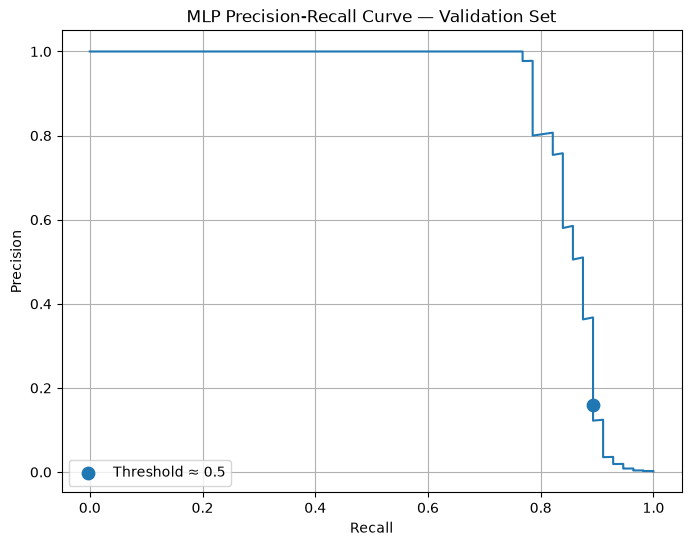

In [141]:
# Import the function required to calculate Precision-Recall values.
from sklearn.metrics import precision_recall_curve

# Calculate Precision and Recall across different probability thresholds.
precision_values, recall_values, threshold_values = precision_recall_curve(
    val_targets_numpy,
    val_probabilities,
)

# Create a Precision-Recall curve plot.
plt.figure(figsize=(8, 6))

# Plot Recall against Precision across the available thresholds.
plt.plot(
    recall_values,
    precision_values,
)

# Mark the Precision and Recall obtained with the current 0.5 threshold.
threshold_index = np.argmin(
    np.abs(threshold_values - THRESHOLD)
)

plt.scatter(
    recall_values[threshold_index],
    precision_values[threshold_index],
    s=80,
    label=f"Threshold ≈ {THRESHOLD}",
)

# Add plot labels and title.
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("MLP Precision-Recall Curve — Validation Set")

# Display the legend and grid.
plt.legend()
plt.grid(True)

# Display the plot.
plt.show()

### 2.14 Threshold Analysis

The effect of different probability thresholds on Precision, Recall, and F1-score is examined using the validation predictions.

This analysis is descriptive and does not yet define an operational threshold.

In [142]:
# Define a set of probability thresholds for diagnostic analysis.
thresholds_to_test = [
    0.10,
    0.50,
    0.70,
    0.80,
    0.90,
    0.95,
    0.99,
    0.999,
]

# Initialize a list to store the metric results for each threshold.
threshold_results = []

# Evaluate the model at each selected threshold.
for threshold in thresholds_to_test:

    # Convert probabilities into binary predictions at the current threshold.
    predictions = (
        val_probabilities >= threshold
    ).astype(int)

    # Calculate Precision at the current threshold.
    precision = precision_score(
        val_targets_numpy,
        predictions,
        zero_division=0,
    )

    # Calculate Recall at the current threshold.
    recall = recall_score(
        val_targets_numpy,
        predictions,
        zero_division=0,
    )

    # Calculate F1-score at the current threshold.
    f1 = f1_score(
        val_targets_numpy,
        predictions,
        zero_division=0,
    )

    # Count the number of transactions classified as fraud.
    predicted_fraud_count = predictions.sum()

    # Store the results for the current threshold.
    threshold_results.append(
        {
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Predicted_Fraud_Count": predicted_fraud_count,
        }
    )

# Create a DataFrame containing the threshold diagnostics.
threshold_results_df = pd.DataFrame(threshold_results)

# Display the results rounded to four decimal places.
threshold_results_df.round(4)

,Threshold,Precision,Recall,F1,Predicted_Fraud_Count
0,0.100,0.0113,0.9464,0.0224,4680
1,0.500,0.1597,0.8929,0.2710,313
2,0.700,0.4153,0.8750,0.5632,118
3,0.800,0.5581,0.8571,0.6761,86
4,0.900,0.7460,0.8393,0.7899,63
5,0.950,0.8000,0.7857,0.7928,55
6,0.990,1.0000,0.7143,0.8333,40
7,0.999,1.0000,0.4643,0.6341,26


## 3. Autoencoder for Fraud Detection

The second Tier 2 model is an Autoencoder designed for anomaly detection.

Unlike the supervised MLP, which learns directly from the fraud labels, the Autoencoder learns to reconstruct the input features from a compressed representation.

For fraud detection, the main idea is to learn the typical structure of legitimate transactions and use the reconstruction error as an anomaly score.

The training process will therefore use legitimate transactions only. Fraud labels will not be used to optimize the Autoencoder parameters.

After training, the reconstruction error will be calculated for the validation and test transactions. Higher reconstruction errors may indicate transactions that differ from the patterns learned from legitimate transactions.

Average Precision (AP), Precision, Recall, F1-score, ROC-AUC, and threshold analysis will be used to evaluate how well the reconstruction error separates fraudulent from legitimate transactions.

The same chronological train, validation, and test split used throughout the project will be preserved.

### 3.1 Autoencoder Training Data

The Autoencoder will be trained using only legitimate transactions from the training set.

The fraud labels will be used only to select legitimate transactions for training. They will not be provided as model inputs or used to calculate the training loss.

The validation and test sets will retain both legitimate and fraudulent transactions so that reconstruction errors can be evaluated as anomaly scores.

In [143]:
# Select only legitimate transactions from the scaled training set.
X_train_autoencoder = X_train[y_train == 0].copy()

# Keep the complete scaled validation set for anomaly detection evaluation.
X_val_autoencoder = X_val.copy()

# Keep the complete scaled test set reserved for final evaluation.
X_test_autoencoder = X_test.copy()

# Display the resulting dataset shapes.
print(f"Autoencoder training shape: {X_train_autoencoder.shape}")
print(f"Validation evaluation shape: {X_val_autoencoder.shape}")
print(f"Test evaluation shape: {X_test_autoencoder.shape}")

Autoencoder training shape: (198980, 32)
Validation evaluation shape: (42721, 32)
Test evaluation shape: (42722, 32)


### 3.2 Convert Autoencoder Data to PyTorch Tensors

The Autoencoder requires PyTorch tensors as input.

The training tensor contains only legitimate transactions, while the validation and test tensors contain all transactions and will be used later to calculate reconstruction errors.

In [144]:
# Convert the Autoencoder training data to NumPy arrays with float32 precision.
X_train_autoencoder_array = X_train_autoencoder.to_numpy(
    dtype=np.float32,
    copy=True,
)

# Convert the validation evaluation data to NumPy arrays with float32 precision.
X_val_autoencoder_array = X_val_autoencoder.to_numpy(
    dtype=np.float32,
    copy=True,
)

# Convert the test evaluation data to NumPy arrays with float32 precision.
X_test_autoencoder_array = X_test_autoencoder.to_numpy(
    dtype=np.float32,
    copy=True,
)

# Convert the NumPy arrays into PyTorch tensors.
X_train_autoencoder_tensor = torch.from_numpy(
    X_train_autoencoder_array
)

X_val_autoencoder_tensor = torch.from_numpy(
    X_val_autoencoder_array
)

X_test_autoencoder_tensor = torch.from_numpy(
    X_test_autoencoder_array
)

# Display the tensor shapes and data types.
print(f"Training tensor shape: {X_train_autoencoder_tensor.shape}")
print(f"Validation tensor shape: {X_val_autoencoder_tensor.shape}")
print(f"Test tensor shape: {X_test_autoencoder_tensor.shape}")

print(f"\nTraining tensor dtype: {X_train_autoencoder_tensor.dtype}")

Training tensor shape: torch.Size([198980, 32])
Validation tensor shape: torch.Size([42721, 32])
Test tensor shape: torch.Size([42722, 32])

Training tensor dtype: torch.float32


### 3.3 Autoencoder DataLoader

The Autoencoder will be trained using mini-batches of legitimate transactions.

The validation and test tensors will be kept as complete evaluation datasets and will not be shuffled during evaluation.

In [145]:
# Create a TensorDataset containing only legitimate training transactions.
autoencoder_train_dataset = TensorDataset(
    X_train_autoencoder_tensor
)

# Define the Autoencoder batch size.
AUTOENCODER_BATCH_SIZE = 1024

# Create a reproducible random generator for training batches.
autoencoder_train_generator = torch.Generator()
autoencoder_train_generator.manual_seed(RANDOM_SEED)

# Create the Autoencoder training DataLoader.
autoencoder_train_loader = DataLoader(
    autoencoder_train_dataset,
    batch_size=AUTOENCODER_BATCH_SIZE,
    shuffle=True,
    generator=autoencoder_train_generator,
)

# Calculate the expected number of training batches.
expected_autoencoder_batches = int(
    np.ceil(
        len(autoencoder_train_dataset)
        / AUTOENCODER_BATCH_SIZE
    )
)

# Display the DataLoader configuration.
print(f"Autoencoder training samples: {len(autoencoder_train_dataset)}")
print(f"Autoencoder batch size: {AUTOENCODER_BATCH_SIZE}")
print(f"Autoencoder training batches: {len(autoencoder_train_loader)}")
print(f"Expected training batches: {expected_autoencoder_batches}")

Autoencoder training samples: 198980
Autoencoder batch size: 1024
Autoencoder training batches: 195
Expected training batches: 195


### 3.4 Autoencoder Configuration

The Autoencoder will use a symmetric architecture with a compressed latent representation.

The input contains 32 features. The encoder will progressively reduce the representation from 32 features to 16 and then to 8 latent features. The decoder will reconstruct the original 32-dimensional input.

The model will use ReLU activation functions in the hidden layers and a linear output layer because the input features have already been transformed using RobustScaler.

In [146]:
# Define the number of input features used by the Autoencoder.
AUTOENCODER_INPUT_DIM = X_train_autoencoder_tensor.shape[1]

# Define the size of the first hidden representation.
AUTOENCODER_HIDDEN_DIM = 16

# Define the size of the compressed latent representation.
AUTOENCODER_LATENT_DIM = 8

# Display the Autoencoder architecture dimensions.
print(f"Input dimension: {AUTOENCODER_INPUT_DIM}")
print(f"Hidden dimension: {AUTOENCODER_HIDDEN_DIM}")
print(f"Latent dimension: {AUTOENCODER_LATENT_DIM}")

Input dimension: 32
Hidden dimension: 16
Latent dimension: 8


### 3.5 Autoencoder Model Definition

The Autoencoder consists of an encoder and a decoder.

The encoder compresses the 32 input features into an 8-dimensional latent representation.

The decoder expands the latent representation back to the original 32-dimensional feature space.

ReLU activation functions are used between the linear layers, while the final decoder layer uses a linear output.

In [147]:
# Define the Autoencoder neural network architecture.
class FraudAutoencoder(nn.Module):

    # Initialize the Autoencoder layers.
    def __init__(
        self,
        input_dim,
        hidden_dim,
        latent_dim,
    ):
        # Initialize the parent PyTorch module.
        super().__init__()

        # Define the encoder that compresses the input features.
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

        # Define the decoder that reconstructs the original features.
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    # Define the forward pass through the Autoencoder.
    def forward(self, x):

        # Generate the compressed latent representation.
        latent = self.encoder(x)

        # Reconstruct the original input from the latent representation.
        reconstruction = self.decoder(latent)

        # Return both the reconstruction and latent representation.
        return reconstruction, latent

### 3.6 Create the Autoencoder

The Autoencoder is instantiated using the input, hidden, and latent dimensions defined above.

The model will be moved to the same computation device used by the MLP.

In [148]:
# Create the Autoencoder using the configured architecture dimensions.
autoencoder = FraudAutoencoder(
    input_dim=AUTOENCODER_INPUT_DIM,
    hidden_dim=AUTOENCODER_HIDDEN_DIM,
    latent_dim=AUTOENCODER_LATENT_DIM,
)

# Move the Autoencoder to the selected computation device.
autoencoder = autoencoder.to(device)

# Display the Autoencoder architecture.
print(autoencoder)

FraudAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
  )
)


### 3.7 Autoencoder Parameter Count

The number of trainable parameters will be calculated to verify the size of the Autoencoder before training.

In [149]:
# Calculate the total number of trainable parameters in the Autoencoder.
autoencoder_trainable_parameters = sum(
    parameter.numel()
    for parameter in autoencoder.parameters()
    if parameter.requires_grad
)

# Display the total number of trainable parameters.
print(
    f"Trainable parameters: {autoencoder_trainable_parameters:,}"
)

Trainable parameters: 1,352


### 3.8 Reconstruction Loss

The Autoencoder will use Mean Squared Error (MSE) as the reconstruction loss.

The input batch itself will be used as the reconstruction target because the model is trained to reproduce the original legitimate transaction features.

No fraud labels will be used during Autoencoder training.

In [150]:
# Define Mean Squared Error as the reconstruction loss.
autoencoder_criterion = nn.MSELoss()

# Display the reconstruction loss function.
print(autoencoder_criterion)

MSELoss()


### 3.9 First Forward Pass

A first forward pass will be performed using one training batch.

The purpose is to verify that the Autoencoder receives the expected input shape and produces a reconstruction with the same 32-dimensional feature space.

In [151]:
# Retrieve the first batch of legitimate transactions.
first_autoencoder_batch = next(
    iter(autoencoder_train_loader)
)

# Extract the input tensor from the batch.
first_batch_features = first_autoencoder_batch[0]

# Move the batch to the selected computation device.
first_batch_features = first_batch_features.to(device)

# Generate the reconstruction and latent representation.
first_reconstruction, first_latent = autoencoder(
    first_batch_features
)

# Display the input, reconstruction, and latent shapes.
print(f"Input shape: {first_batch_features.shape}")
print(f"Latent shape: {first_latent.shape}")
print(f"Reconstruction shape: {first_reconstruction.shape}")

Input shape: torch.Size([1024, 32])
Latent shape: torch.Size([1024, 8])
Reconstruction shape: torch.Size([1024, 32])


### 3.10 Initial Reconstruction Loss

The initial reconstruction loss will be calculated before training.

This provides a reference point for the reconstruction error before the Autoencoder has learned the structure of legitimate transactions.

In [152]:
# Calculate the reconstruction loss before Autoencoder training.
initial_reconstruction_loss = autoencoder_criterion(
    first_reconstruction,
    first_batch_features,
)

# Display the initial reconstruction loss.
print(
    f"Initial reconstruction loss: "
    f"{initial_reconstruction_loss.item():.6f}"
)

Initial reconstruction loss: 1.776900


### 3.11 Autoencoder Optimizer

The Autoencoder will be trained using the Adam optimizer.

The learning rate is set to 0.001 to provide a consistent starting point with the MLP training configuration.

In [153]:
# Define the learning rate for Autoencoder training.
AUTOENCODER_LEARNING_RATE = 0.001

# Create the Adam optimizer for the Autoencoder parameters.
autoencoder_optimizer = torch.optim.Adam(
    autoencoder.parameters(),
    lr=AUTOENCODER_LEARNING_RATE,
)

# Display the configured learning rate.
print(
    f"Autoencoder learning rate: "
    f"{AUTOENCODER_LEARNING_RATE}"
)

Autoencoder learning rate: 0.001


### 3.12 Single Autoencoder Training Step

A single optimization step will be performed before the full training loop.

This step verifies that the reconstruction loss can be backpropagated and that the Autoencoder parameters can be updated successfully.

In [154]:
# Put the Autoencoder into training mode.
autoencoder.train()

# Clear gradients from any previous optimization step.
autoencoder_optimizer.zero_grad()

# Generate a reconstruction for the first training batch.
step_reconstruction, _ = autoencoder(
    first_batch_features
)

# Calculate the reconstruction loss.
step_loss = autoencoder_criterion(
    step_reconstruction,
    first_batch_features,
)

# Calculate gradients through backpropagation.
step_loss.backward()

# Update the Autoencoder parameters.
autoencoder_optimizer.step()

# Display the loss before the parameter update.
print(
    f"Single training step loss: "
    f"{step_loss.item():.6f}"
)

Single training step loss: 1.776900


### 3.13 Reconstruction Loss After One Update

The reconstruction loss will be calculated again after the single optimization step.

This allows us to verify whether the parameter update reduced the reconstruction error on the same training batch.

In [155]:
# Put the Autoencoder into evaluation mode for the loss check.
autoencoder.eval()

# Disable gradient calculation because no parameter update is performed.
with torch.no_grad():

    # Generate a new reconstruction using the updated parameters.
    updated_reconstruction, _ = autoencoder(
        first_batch_features
    )

    # Calculate the reconstruction loss after the parameter update.
    updated_reconstruction_loss = autoencoder_criterion(
        updated_reconstruction,
        first_batch_features,
    )

# Display the updated reconstruction loss.
print(
    f"Reconstruction loss after one update: "
    f"{updated_reconstruction_loss.item():.6f}"
)

Reconstruction loss after one update: 1.772905


### 3.14 Autoencoder Training Configuration

The Autoencoder will be trained for a maximum of 50 epochs.

Early stopping will be based on validation reconstruction loss. Training will stop when the validation reconstruction loss does not improve for 7 consecutive epochs.

The model state with the lowest validation reconstruction loss will be retained.

In [156]:
# Define the maximum number of Autoencoder training epochs.
AUTOENCODER_MAX_EPOCHS = 50

# Define the number of consecutive epochs allowed without validation loss improvement.
AUTOENCODER_EARLY_STOPPING_PATIENCE = 7

# Display the Autoencoder training configuration.
print(
    f"Maximum epochs: {AUTOENCODER_MAX_EPOCHS}"
)
print(
    f"Early stopping patience: "
    f"{AUTOENCODER_EARLY_STOPPING_PATIENCE}"
)

Maximum epochs: 50
Early stopping patience: 7


### 3.15 Full Autoencoder Training

The Autoencoder will now be trained using legitimate training transactions only.

The validation reconstruction loss will be monitored after each epoch.

The model parameters from the epoch with the lowest validation reconstruction loss will be retained.

In [157]:
# Recreate the Autoencoder with freshly initialized parameters.
autoencoder = FraudAutoencoder(
    input_dim=AUTOENCODER_INPUT_DIM,
    hidden_dim=AUTOENCODER_HIDDEN_DIM,
    latent_dim=AUTOENCODER_LATENT_DIM,
)

# Move the new Autoencoder to the selected computation device.
autoencoder = autoencoder.to(device)

# Recreate the Adam optimizer for the new Autoencoder parameters.
autoencoder_optimizer = torch.optim.Adam(
    autoencoder.parameters(),
    lr=AUTOENCODER_LEARNING_RATE,
)

# Initialize the best validation reconstruction loss.
best_autoencoder_val_loss = np.inf

# Initialize the best epoch tracker.
best_autoencoder_epoch = 0

# Initialize the early-stopping counter.
autoencoder_epochs_without_improvement = 0

# Initialize a list to store the Autoencoder training history.
autoencoder_training_history = []

# Train the Autoencoder for up to the configured maximum number of epochs.
for epoch in range(1, AUTOENCODER_MAX_EPOCHS + 1):

    # Put the Autoencoder into training mode.
    autoencoder.train()

    # Initialize the accumulated training loss.
    running_train_loss = 0.0

    # Iterate through all legitimate training batches.
    for (batch_features,) in autoencoder_train_loader:

        # Move the training batch to the selected computation device.
        batch_features = batch_features.to(device)

        # Clear gradients from the previous optimization step.
        autoencoder_optimizer.zero_grad()

        # Generate the reconstruction.
        batch_reconstruction, _ = autoencoder(batch_features)

        # Calculate the reconstruction loss.
        batch_loss = autoencoder_criterion(
            batch_reconstruction,
            batch_features,
        )

        # Calculate gradients through backpropagation.
        batch_loss.backward()

        # Update the Autoencoder parameters.
        autoencoder_optimizer.step()

        # Accumulate the batch loss weighted by batch size.
        running_train_loss += (
            batch_loss.item()
            * batch_features.size(0)
        )

    # Calculate the mean training reconstruction loss.
    train_loss = (
        running_train_loss
        / len(autoencoder_train_loader.dataset)
    )

    # Put the Autoencoder into evaluation mode.
    autoencoder.eval()

    # Disable gradient calculation during validation.
    with torch.no_grad():

        # Move the complete validation tensor to the selected device.
        validation_features = X_val_autoencoder_tensor.to(device)

        # Generate validation reconstructions.
        validation_reconstruction, _ = autoencoder(
            validation_features
        )

        # Calculate the validation reconstruction loss.
        val_loss = autoencoder_criterion(
            validation_reconstruction,
            validation_features,
        ).item()

    # Store the current epoch results.
    autoencoder_training_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
        }
    )

    # Check whether validation reconstruction loss improved.
    if val_loss < best_autoencoder_val_loss:

        # Update the best validation reconstruction loss.
        best_autoencoder_val_loss = val_loss

        # Store the best epoch.
        best_autoencoder_epoch = epoch

        # Reset the early-stopping counter.
        autoencoder_epochs_without_improvement = 0

        # Save a CPU copy of the best Autoencoder parameters.
        best_autoencoder_state = {
            key: value.detach().cpu().clone()
            for key, value in autoencoder.state_dict().items()
        }

        # Record that the current epoch improved validation loss.
        improvement_status = "improved"

    else:

        # Increase the counter when validation loss does not improve.
        autoencoder_epochs_without_improvement += 1

        # Record that validation loss did not improve.
        improvement_status = "no improvement"

    # Print the current training and validation losses.
    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"{improvement_status}"
    )

    # Stop training after the configured patience period.
    if (
        autoencoder_epochs_without_improvement
        >= AUTOENCODER_EARLY_STOPPING_PATIENCE
    ):

        # Report the early-stopping event.
        print(
            f"Early stopping triggered after epoch {epoch}. "
            f"Best epoch: {best_autoencoder_epoch}."
        )

        # Exit the training loop.
        break

# Restore the Autoencoder parameters from the best validation epoch.
autoencoder.load_state_dict(best_autoencoder_state)

# Move the restored model to the selected computation device.
autoencoder = autoencoder.to(device)

# Display the final training reference results.
print(
    f"\nBest validation reconstruction loss: "
    f"{best_autoencoder_val_loss:.6f}"
)
print(
    f"Best epoch: {best_autoencoder_epoch}"
)

Epoch 01 | Train Loss: 1.517855 | Val Loss: 1.547928 | improved
Epoch 02 | Train Loss: 0.983497 | Val Loss: 1.107670 | improved
Epoch 03 | Train Loss: 0.743883 | Val Loss: 0.895074 | improved
Epoch 04 | Train Loss: 0.623004 | Val Loss: 0.769643 | improved
Epoch 05 | Train Loss: 0.552032 | Val Loss: 0.718537 | improved
Epoch 06 | Train Loss: 0.517526 | Val Loss: 0.684886 | improved
Epoch 07 | Train Loss: 0.497012 | Val Loss: 0.655255 | improved
Epoch 08 | Train Loss: 0.480776 | Val Loss: 0.631434 | improved
Epoch 09 | Train Loss: 0.465921 | Val Loss: 0.608670 | improved
Epoch 10 | Train Loss: 0.452044 | Val Loss: 0.588294 | improved
Epoch 11 | Train Loss: 0.442196 | Val Loss: 0.576743 | improved
Epoch 12 | Train Loss: 0.433913 | Val Loss: 0.567623 | improved
Epoch 13 | Train Loss: 0.426957 | Val Loss: 0.557314 | improved
Epoch 14 | Train Loss: 0.420797 | Val Loss: 0.536425 | improved
Epoch 15 | Train Loss: 0.415190 | Val Loss: 0.529760 | improved
Epoch 16 | Train Loss: 0.410724 | Val Lo

### 3.16 Reconstruction Error on the Validation Set

The trained Autoencoder will be used to reconstruct every transaction in the validation set.

A reconstruction error will be calculated separately for each transaction.

The resulting reconstruction error will be used as the anomaly score for fraud detection.

In [158]:
# Put the trained Autoencoder into evaluation mode.
autoencoder.eval()

# Move the complete validation dataset to the selected device.
validation_features = X_val_autoencoder_tensor.to(device)

# Disable gradient calculation during inference.
with torch.no_grad():

    # Generate reconstructions for all validation transactions.
    validation_reconstruction, _ = autoencoder(
        validation_features
    )

    # Calculate the squared reconstruction error for each feature.
    validation_squared_error = (
        validation_features - validation_reconstruction
    ) ** 2

    # Calculate the mean reconstruction error for each transaction.
    validation_reconstruction_error = (
        validation_squared_error.mean(dim=1)
    )

# Move the reconstruction errors to the CPU and convert them to NumPy.
validation_reconstruction_error = (
    validation_reconstruction_error
    .cpu()
    .numpy()
)

# Display the reconstruction error array shape.
print(
    f"Validation reconstruction error shape: "
    f"{validation_reconstruction_error.shape}"
)

# Display basic reconstruction error statistics.
print(
    f"Mean reconstruction error: "
    f"{validation_reconstruction_error.mean():.6f}"
)

print(
    f"Median reconstruction error: "
    f"{np.median(validation_reconstruction_error):.6f}"
)

print(
    f"Maximum reconstruction error: "
    f"{validation_reconstruction_error.max():.6f}"
)

Validation reconstruction error shape: (42721,)
Mean reconstruction error: 0.454700
Median reconstruction error: 0.344324
Maximum reconstruction error: 39.299641


### 3.17 Reconstruction Error by Class

The validation reconstruction errors will be compared between legitimate and fraudulent transactions.

The fraud labels are not used during Autoencoder training. They are used here only for evaluation.

If fraudulent transactions generally produce higher reconstruction errors, the reconstruction error may provide useful anomaly detection capability.

In [159]:
# Create a validation DataFrame containing reconstruction errors and true labels.
validation_reconstruction_results = pd.DataFrame(
    {
        "Class": y_val.to_numpy(),
        "Reconstruction_Error": validation_reconstruction_error,
    }
)

# Calculate reconstruction error statistics for legitimate transactions.
legitimate_error = validation_reconstruction_results.loc[
    validation_reconstruction_results["Class"] == 0,
    "Reconstruction_Error",
]

# Calculate reconstruction error statistics for fraudulent transactions.
fraud_error = validation_reconstruction_results.loc[
    validation_reconstruction_results["Class"] == 1,
    "Reconstruction_Error",
]

# Display reconstruction error statistics by class.
print("Legitimate transactions:")
print(legitimate_error.describe())

print("\nFraudulent transactions:")
print(fraud_error.describe())

Legitimate transactions:
count    42665.000000
mean         0.448015
std          0.540505
min          0.076918
25%          0.227201
50%          0.343950
75%          0.560882
max         39.299641
Name: Reconstruction_Error, dtype: float64

Fraudulent transactions:
count    56.000000
mean      5.547912
std       3.076105
min       0.204261
25%       3.279254
50%       5.832056
75%       7.648623
max      14.141395
Name: Reconstruction_Error, dtype: float64


### 3.18 Autoencoder Average Precision

The reconstruction error will be evaluated as an anomaly score using Average Precision (AP).

Higher reconstruction errors indicate a higher likelihood of anomalous behavior.

The fraud labels are used only for evaluation and are not used during Autoencoder training.

In [160]:
# Extract the validation fraud labels as a NumPy array.
y_val_autoencoder = y_val.to_numpy()

# Calculate Average Precision using reconstruction error as the anomaly score.
autoencoder_val_ap = average_precision_score(
    y_val_autoencoder,
    validation_reconstruction_error,
)

# Display the validation Average Precision.
print(
    f"Autoencoder validation AP: "
    f"{autoencoder_val_ap:.6f}"
)

Autoencoder validation AP: 0.285407


### 3.19 Reconstruction Error Threshold Analysis

The reconstruction error will be evaluated at several candidate thresholds.

For each threshold, transactions with reconstruction errors above the threshold will be classified as fraudulent.

Precision, Recall, F1-score, and the number of predicted fraudulent transactions will be calculated using the validation set.

The validation set will be used only for threshold analysis. The test set remains untouched.

In [161]:
# Define candidate reconstruction error thresholds for validation analysis.
AUTOENCODER_THRESHOLDS = [
    0.5,
    1.0,
    2.0,
    3.0,
    4.0,
    5.0,
    6.0,
    8.0,
    10.0,
]

# Initialize a list to store threshold evaluation results.
autoencoder_threshold_results = []

# Evaluate each candidate reconstruction error threshold.
for threshold in AUTOENCODER_THRESHOLDS:

    # Classify transactions above the threshold as fraudulent.
    predictions = (
        validation_reconstruction_error >= threshold
    ).astype(int)

    # Calculate precision at the current threshold.
    threshold_precision = precision_score(
        y_val_autoencoder,
        predictions,
        zero_division=0,
    )

    # Calculate recall at the current threshold.
    threshold_recall = recall_score(
        y_val_autoencoder,
        predictions,
        zero_division=0,
    )

    # Calculate F1-score at the current threshold.
    threshold_f1 = f1_score(
        y_val_autoencoder,
        predictions,
        zero_division=0,
    )

    # Count the number of transactions classified as fraudulent.
    predicted_fraud_count = predictions.sum()

    # Store the threshold evaluation results.
    autoencoder_threshold_results.append(
        {
            "Threshold": threshold,
            "Precision": threshold_precision,
            "Recall": threshold_recall,
            "F1": threshold_f1,
            "Predicted_Fraud_Count": predicted_fraud_count,
        }
    )

# Convert the results into a DataFrame for inspection.
autoencoder_threshold_results = pd.DataFrame(
    autoencoder_threshold_results
)

# Display the threshold analysis results.
display(autoencoder_threshold_results)

,Threshold,Precision,Recall,F1,Predicted_Fraud_Count
0,0.5,0.003995,0.946429,0.007956,13268
1,1.0,0.024854,0.910714,0.048387,2052
2,2.0,0.173285,0.857143,0.288288,277
3,3.0,0.266667,0.785714,0.398190,165
4,4.0,0.307018,0.625000,0.411765,114
5,5.0,0.344444,0.553571,0.424658,90
6,6.0,0.417910,0.500000,0.455285,67
7,8.0,0.400000,0.250000,0.307692,35
8,10.0,0.125000,0.035714,0.055556,16


### 3.20 Reconstruction Error Distribution by Class

The validation reconstruction error distributions will be visualized separately for legitimate and fraudulent transactions.

The visualization will help assess the degree of overlap between the two classes and provide a visual interpretation of the reconstruction error statistics.

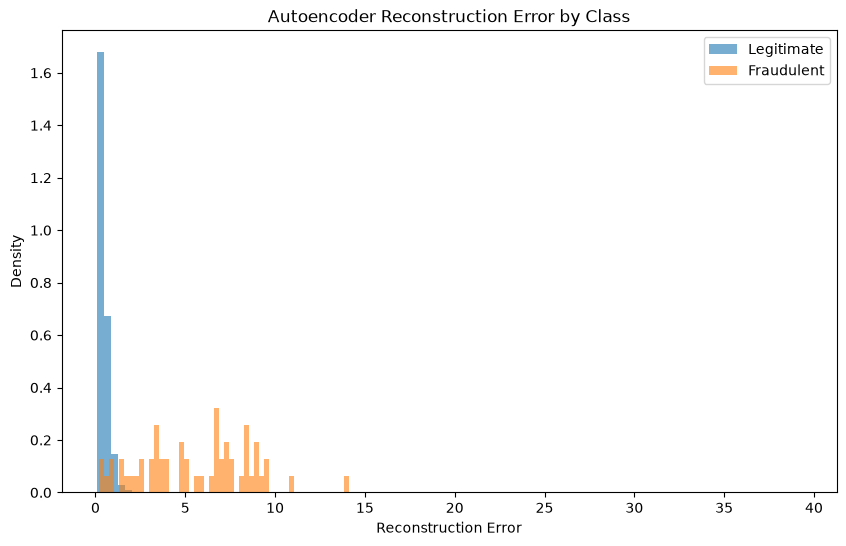

In [162]:
# Create separate reconstruction error arrays for each class.
legitimate_reconstruction_error = validation_reconstruction_results.loc[
    validation_reconstruction_results["Class"] == 0,
    "Reconstruction_Error",
].to_numpy()

fraud_reconstruction_error = validation_reconstruction_results.loc[
    validation_reconstruction_results["Class"] == 1,
    "Reconstruction_Error",
].to_numpy()

# Create a figure for the reconstruction error distributions.
plt.figure(figsize=(10, 6))

# Plot the legitimate transaction reconstruction errors.
plt.hist(
    legitimate_reconstruction_error,
    bins=100,
    alpha=0.6,
    density=True,
    label="Legitimate",
)

# Plot the fraudulent transaction reconstruction errors.
plt.hist(
    fraud_reconstruction_error,
    bins=50,
    alpha=0.6,
    density=True,
    label="Fraudulent",
)

# Add the chart title and axis labels.
plt.title("Autoencoder Reconstruction Error by Class")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")

# Display the class legend.
plt.legend()

# Display the plot.
plt.show()

### 3.21 Log-Scale Reconstruction Error Distribution

The reconstruction error distributions will be visualized using a logarithmic x-axis.

The logarithmic scale is used because reconstruction errors are strongly right-skewed and contain values across a wide range.

This visualization provides a clearer view of the separation and overlap between legitimate and fraudulent transactions.

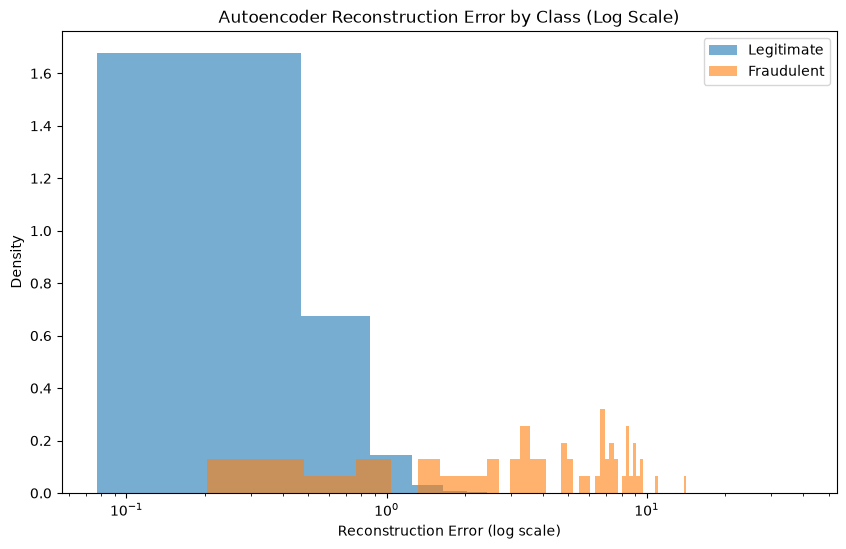

In [163]:
# Create a figure for the log-scale reconstruction error distributions.
plt.figure(figsize=(10, 6))

# Plot legitimate transaction reconstruction errors.
plt.hist(
    legitimate_reconstruction_error,
    bins=100,
    alpha=0.6,
    density=True,
    label="Legitimate",
)

# Plot fraudulent transaction reconstruction errors.
plt.hist(
    fraud_reconstruction_error,
    bins=50,
    alpha=0.6,
    density=True,
    label="Fraudulent",
)

# Use a logarithmic scale for the reconstruction error axis.
plt.xscale("log")

# Add the chart title and axis labels.
plt.title("Autoencoder Reconstruction Error by Class (Log Scale)")
plt.xlabel("Reconstruction Error (log scale)")
plt.ylabel("Density")

# Display the class legend.
plt.legend()

# Display the plot.
plt.show()

### 3.22 Tier 1, MLP and Autoencoder Validation Comparison

The validation performance of the Tier 1 models, MLP, and Autoencoder will be consolidated for comparison.

Average Precision (AP) remains the primary comparison metric.

The Autoencoder uses reconstruction error as its anomaly score, while the supervised models use predicted fraud probabilities.

The test set remains reserved for final evaluation.

In [164]:
# Define candidate reconstruction error thresholds for the current
# Autoencoder reconstruction errors.
AUTOENCODER_THRESHOLDS = [
    0.5,
    1.0,
    2.0,
    3.0,
    4.0,
    5.0,
    6.0,
    8.0,
    10.0,
]

# Initialize a list to store the updated threshold evaluation results.
autoencoder_threshold_results = []

# Evaluate each candidate reconstruction error threshold.
for threshold in AUTOENCODER_THRESHOLDS:

    # Classify transactions above the threshold as fraudulent.
    predictions = (
        validation_reconstruction_error >= threshold
    ).astype(int)

    # Calculate precision at the current threshold.
    threshold_precision = precision_score(
        y_val_autoencoder,
        predictions,
        zero_division=0,
    )

    # Calculate recall at the current threshold.
    threshold_recall = recall_score(
        y_val_autoencoder,
        predictions,
        zero_division=0,
    )

    # Calculate F1-score at the current threshold.
    threshold_f1 = f1_score(
        y_val_autoencoder,
        predictions,
        zero_division=0,
    )

    # Count the number of transactions classified as fraudulent.
    predicted_fraud_count = predictions.sum()

    # Store the threshold evaluation results.
    autoencoder_threshold_results.append(
        {
            "Threshold": threshold,
            "Precision": threshold_precision,
            "Recall": threshold_recall,
            "F1": threshold_f1,
            "Predicted_Fraud_Count": predicted_fraud_count,
        }
    )

# Convert the results into a DataFrame.
autoencoder_threshold_results = pd.DataFrame(
    autoencoder_threshold_results
)

# Display the updated threshold analysis.
display(autoencoder_threshold_results)

,Threshold,Precision,Recall,F1,Predicted_Fraud_Count
0,0.5,0.003995,0.946429,0.007956,13268
1,1.0,0.024854,0.910714,0.048387,2052
2,2.0,0.173285,0.857143,0.288288,277
3,3.0,0.266667,0.785714,0.398190,165
4,4.0,0.307018,0.625000,0.411765,114
5,5.0,0.344444,0.553571,0.424658,90
6,6.0,0.417910,0.500000,0.455285,67
7,8.0,0.400000,0.250000,0.307692,35
8,10.0,0.125000,0.035714,0.055556,16


In [165]:
# Recalculate Average Precision directly from the current validation labels
# and the current Autoencoder reconstruction errors.
recalculated_autoencoder_val_ap = average_precision_score(
    y_val_autoencoder,
    validation_reconstruction_error,
)

# Display the previously stored and newly recalculated AP values.
print(
    f"Stored Autoencoder validation AP: "
    f"{autoencoder_val_ap:.6f}"
)

print(
    f"Recalculated Autoencoder validation AP: "
    f"{recalculated_autoencoder_val_ap:.6f}"
)

# Check whether the reconstruction error array is unchanged from the
# values currently used for the Autoencoder evaluation.
print(
    f"Reconstruction error observations: "
    f"{len(validation_reconstruction_error)}"
)

Stored Autoencoder validation AP: 0.285407
Recalculated Autoencoder validation AP: 0.285407
Reconstruction error observations: 42721


In [166]:
# Update the Autoencoder AP in the consolidated validation comparison.
validation_model_comparison.loc[
    validation_model_comparison["Model"] == "Autoencoder",
    "AP",
] = autoencoder_val_ap

# Sort the models by validation Average Precision in descending order.
validation_model_comparison = validation_model_comparison.sort_values(
    by="AP",
    ascending=False,
).reset_index(drop=True)

# Display the updated validation comparison.
display(validation_model_comparison)

,Model,AP
0,Random Forest,0.858000
1,MLP,0.857221
2,XGBoost,0.828400
3,Logistic Regression,0.784900
4,LightGBM,0.681400
5,Autoencoder,0.285407


### 3.23 Autoencoder Results Summary

The Autoencoder was trained exclusively on legitimate transactions from the training set.

The model used a 32-16-8-16-32 architecture with 1,352 trainable parameters and Mean Squared Error as the reconstruction loss.

Training reached the maximum of 50 epochs, with the best validation reconstruction loss of 0.454701 achieved at epoch 50.

The reconstruction error showed a substantial distributional difference between legitimate and fraudulent validation transactions. However, some legitimate transactions also produced high reconstruction errors.

Using reconstruction error as the anomaly score, the Autoencoder achieved a validation Average Precision (AP) of 0.285407.

The best F1-score within the evaluated threshold grid was 0.455285 at a reconstruction error threshold of 6.0, with 41.79% precision and 50.00% recall.

Compared with the supervised models evaluated in this project, the Autoencoder achieved substantially lower Average Precision. This indicates that, for this dataset, reconstruction-based anomaly detection was less effective for fraud ranking than supervised fraud classification.

The Autoencoder results will therefore be retained as an evaluated Tier 2 approach, without selecting it as the leading model.

### 3.24 Save Autoencoder Validation Results

The Autoencoder validation results will be stored in a structured dictionary.

The stored results include the validation Average Precision, the best validation reconstruction loss, the best training epoch, and the best F1-score observed during the evaluated threshold analysis.

These results will support the final model comparison without exposing the test set to the model development process.

In [167]:
# Identify the threshold with the highest validation F1-score.
best_autoencoder_threshold_row = (
    autoencoder_threshold_results.loc[
        autoencoder_threshold_results["F1"].idxmax()
    ]
)

# Store the verified Autoencoder validation results.
autoencoder_validation_results = {
    "validation_ap": autoencoder_val_ap,
    "best_validation_reconstruction_loss": 0.4547005593776703,
    "best_epoch": 50,
    "best_threshold": best_autoencoder_threshold_row["Threshold"],
    "best_threshold_precision": best_autoencoder_threshold_row["Precision"],
    "best_threshold_recall": best_autoencoder_threshold_row["Recall"],
    "best_threshold_f1": best_autoencoder_threshold_row["F1"],
}

# Display the verified validation results.
for metric_name, metric_value in autoencoder_validation_results.items():
    print(f"{metric_name}: {metric_value}")

validation_ap: 0.28540727476625827
best_validation_reconstruction_loss: 0.4547005593776703
best_epoch: 50
best_threshold: 6.0
best_threshold_precision: 0.417910447761194
best_threshold_recall: 0.5
best_threshold_f1: 0.45528455284552843
